## Imports
All Python dependencies used by this notebook.

In [1]:
import os
import sys
import time
from datetime import datetime, timezone

import pandas as pd
import torch
from PIL import Image
from transformers import AutoProcessor, Gemma3ForConditionalGeneration

from kaggle_secrets import UserSecretsClient
from huggingface_hub import login

## Setup
Configure filesystem paths, create output directories, and authenticate with Hugging Face.

In [2]:
# ── Paths ─────────────────────────────────────────────────────────────────────
INPUT = "/kaggle/input/datasets/yanncohen/ebbinghaus-illusion-benchmark"
WORK  = "/kaggle/working"
os.makedirs(f"{WORK}/images_eval", exist_ok=True)
os.makedirs(f"{WORK}/output",      exist_ok=True)

user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("HF_TOKEN")
login(token=hf_token)

## Load Data
Read the pre-generated trial table and prompt templates from the Kaggle dataset.

In [3]:
trials  = pd.read_csv(f"{INPUT}/data/trials.csv")
prompts = pd.read_csv(f"{INPUT}/data/prompts.csv")
print(f"Loaded {len(trials)} trials")

Loaded 20 trials


## Prepare Evaluation Images
Copy stimulus images with ground-truth info stripped from filenames, so the model can't cheat.

In [4]:
sys.path.insert(0, f"{INPUT}/py/src")
from strip_answer import strip_answer_from_images

trials["file_path"] = trials["file_path"].apply(
    lambda p: f"{INPUT}/images/{os.path.basename(p)}"
)
trials = strip_answer_from_images(trials, output_dir=f"{WORK}/images_eval")

Copied 20 images to /kaggle/working/images_eval with answer-stripped filenames.


## Load Model
Load the Gemma 3 4B-IT model and processor onto GPU.

In [5]:
model_id  = "google/gemma-3-4b-it"
processor = AutoProcessor.from_pretrained(model_id)
model     = Gemma3ForConditionalGeneration.from_pretrained(
                model_id, device_map="cuda", torch_dtype=torch.bfloat16
            )

The image processor of type `Gemma3ImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/883 [00:00<?, ?it/s]

## Run Evaluation
Loop over every (prompt × trial) combination: build a chat message with the stimulus image, generate a response, parse the answer, and record the result.

In [6]:
def get_directions(orientation):
    if orientation == "horizontal":
        return "left", "right"
    elif orientation == "vertical":
        return "top", "bottom"
    elif orientation == "diagonal":
        return "upper-left", "lower-right"
    else:
        raise ValueError(f"Unknown orientation: {orientation}")

def parse_response(raw: str, direction_a: str, direction_b: str, response_format: str) -> str:
    """Extract the answer token from raw response."""
    if response_format == "free_text":
        # Extract answer after "ANSWER:" marker
        if "answer:" in raw:
            raw = raw.split("answer:")[-1].strip()
    if direction_a in raw:
        return direction_a
    if direction_b in raw:
        return direction_b
    if "equal" in raw:
        return "equal"
    return "unknown"

results = []

for _, prompt_row in prompts.iterrows():
    prompt_id       = prompt_row["prompt_id"]
    prompt_template = prompt_row["user_prompt_template"]
    response_format = prompt_row["response_format"]

    for _, row in trials.iterrows():
        direction_a, direction_b = get_directions(row["orientation"])

        raw_text = prompt_template.format(
            direction_a=direction_a,
            direction_b=direction_b,
            test_a_shape=row["test_a_shape"],
            test_b_shape=row["test_b_shape"]
        )

        messages = [
            {"role": "user", "content": [{"type": "image"}, {"type": "text", "text": raw_text}]}
        ]

        chat_prompt = processor.apply_chat_template(messages, add_generation_prompt=True)
        image  = Image.open(row["file_path"])
        inputs = processor(
            images=image,
            text=chat_prompt,
            return_tensors="pt"
        ).to(model.device)

        t0 = time.time()
        with torch.no_grad():
            output = model.generate(**inputs, max_new_tokens=50)  # more tokens for free_text
        latency_ms = round((time.time() - t0) * 1000)

        input_len = inputs["input_ids"].shape[-1]
        response  = processor.decode(output[0][input_len:], skip_special_tokens=True).strip().lower()
        parsed    = parse_response(response, direction_a, direction_b, response_format)

        expected_map = {"a": direction_a, "b": direction_b, "equal": "equal"}
        expected     = expected_map[row["true_larger"]]

        results.append({
            "eval_id":             len(results) + 1,
            "trial_id":            row["trial_id"],
            "prompt_id":           prompt_id,
            "provider":            "google",
            "model":               "gemma-3-4b-it",
            "model_version":       "NA",
            "temperature":         0,
            "max_tokens":          50,
            "response_larger":     "a" if parsed == direction_a else ("b" if parsed == direction_b else parsed),
            "response_confidence": None,
            "raw_response":        response,
            "latency_ms":          latency_ms,
            "timestamp":           datetime.now(timezone.utc).strftime("%Y-%m-%dT%H:%M:%SZ"),
            "error":               "NA"
        })

print(f"Total evals: {len(results)}")  # should be 80 (20 trials × 4 prompts × 1 model)

Total evals: 80


## Save & Summarize
Export raw evaluation results to CSV (optional, for persistence across Kaggle sessions) and print a quick breakdown by prompt.

In [7]:
evals = pd.DataFrame(results)

# Optional: persist raw evals to disk (useful on Kaggle to avoid re-running)
# evals.to_csv(f"{WORK}/output/py-hg-evals.csv", index=False)

print(f"{len(evals)} evals recorded")
evals.groupby("prompt_id")["response_larger"].value_counts()

80 evals recorded


prompt_id  response_larger
1          a                  11
           b                   9
2          b                  14
           a                   6
3          a                  16
           unknown             4
4          b                  12
           a                   8
Name: count, dtype: int64

## Analyze Results
Run Phase 3 analysis: join evals with trial/prompt metadata, compute accuracy and bias metrics, and display all diagnostic plots inline.

The `analyze` module has no dependency on `inspect_ai`, so it imports cleanly on Kaggle. We pass the in-memory `evals` DataFrame directly — no intermediate CSV needed.

Analysis complete. Metrics available in results['metrics']. Plots available in results['plots'].


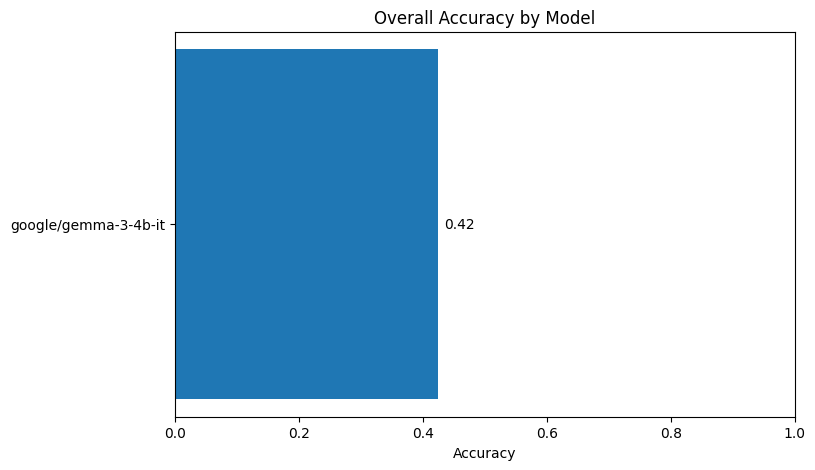

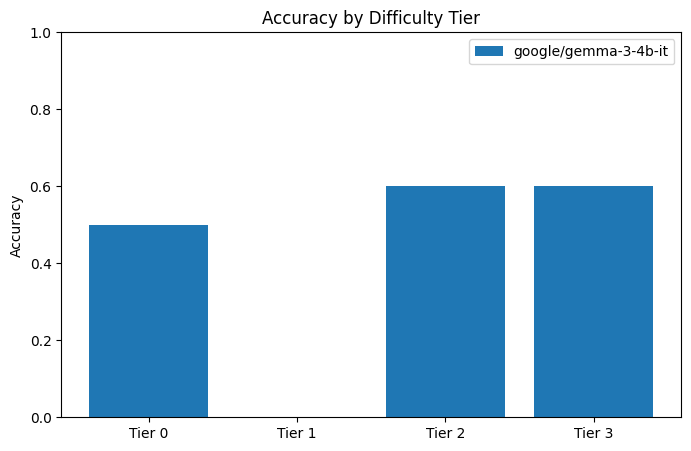

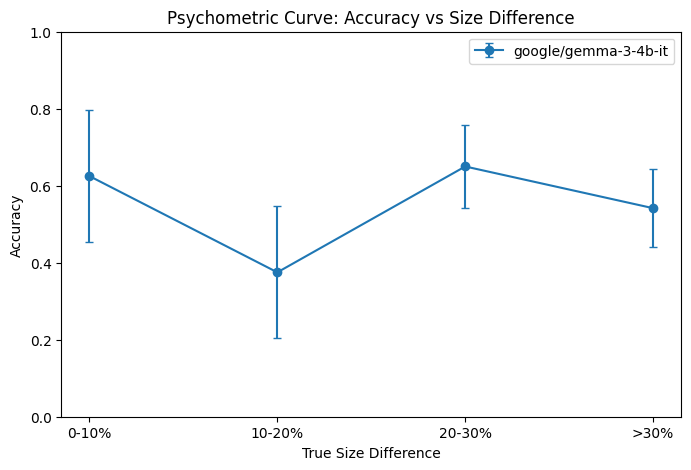

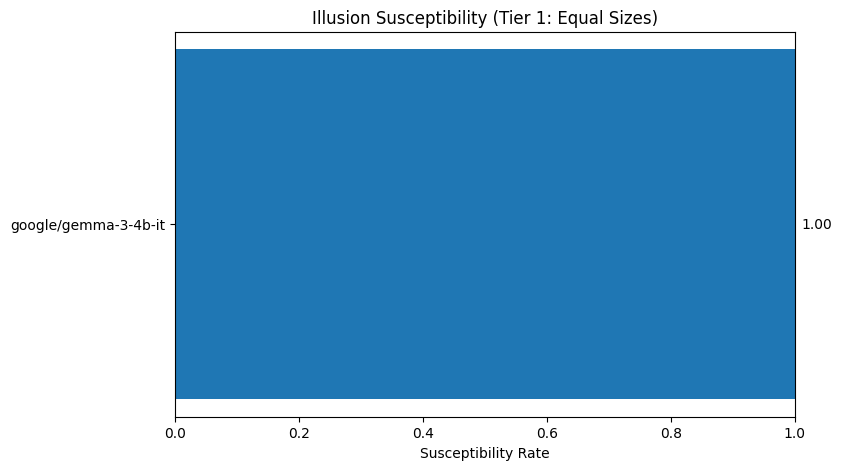

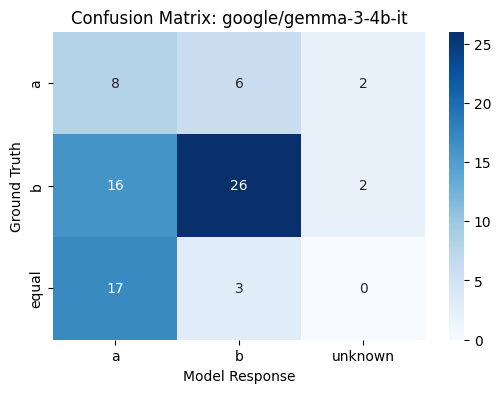

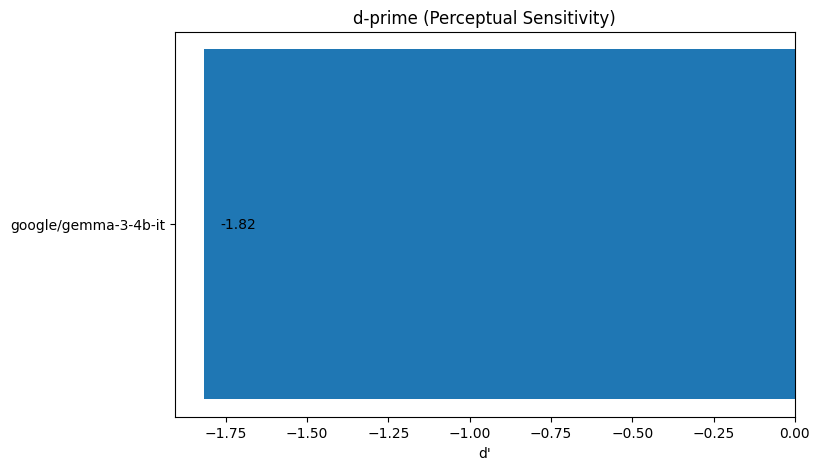

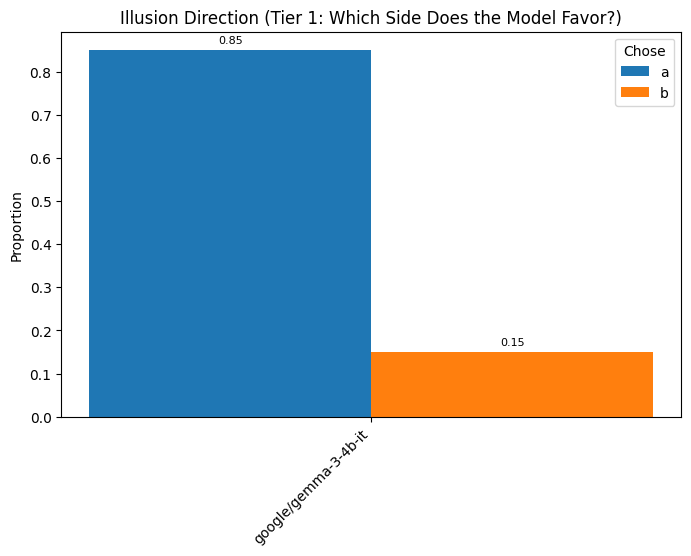

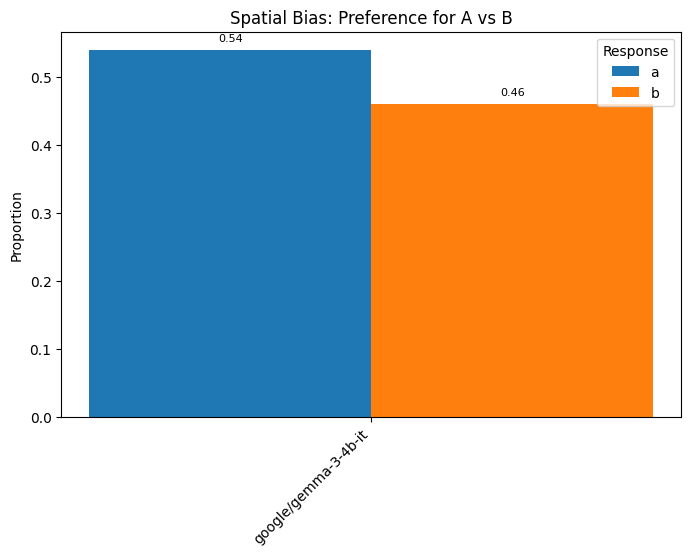

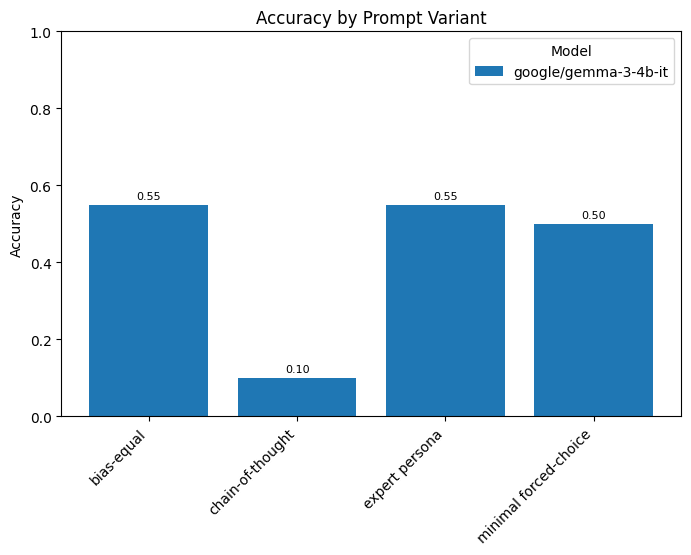

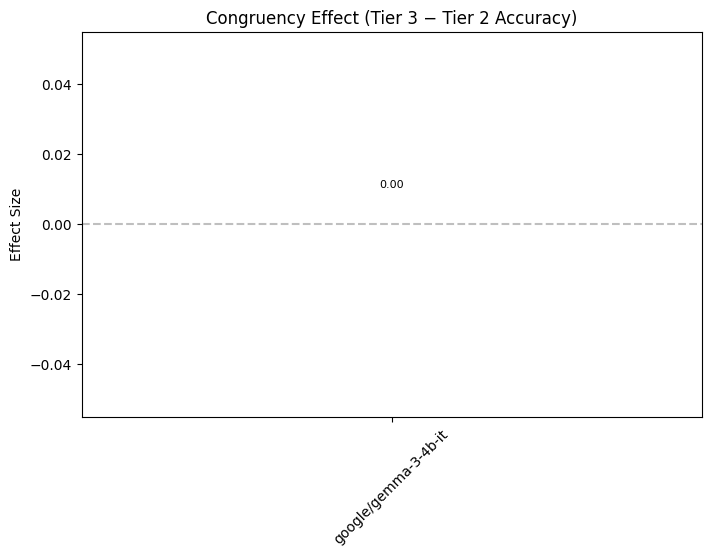

In [8]:
from analyze import analyze_results

analysis = analyze_results(
    show_plots=False,
    evals_df=evals,
    trials_path=f"{INPUT}/data/trials.csv",
    prompts_path=f"{INPUT}/data/prompts.csv",
)